In [2]:
# Load required libraries for data manipulation, visualization, and file input
# tidyverse: core data wrangling and ggplot2 visualization
# lubridate: date handling for time-based analysis
# readxl: reading Excel files (VICE dataset)
# scales: formatting axes and labels (percentages)
# treemapify: treemap visualizations for hierarchical data

library(tidyverse)
library(lubridate)
library(readxl)
library(scales)
library(treemapify)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor




In [3]:
# Define file paths to the four required datasets
# Using absolute paths ensures reproducibility across sessions

mw_path = "C:/Users/shagh/DSC530/envs/book_env1/Hands_On_Data_with_panda_edition2/winter 2026/Data presentation/week 5&6/KiaHyundaiMilwaukeeData.csv"
map_path = "C:/Users/shagh/DSC530/envs/book_env1/Hands_On_Data_with_panda_edition2/winter 2026/Data presentation/week 5&6/carTheftsMap.csv"
thefts_path = "C:/Users/shagh/DSC530/envs/book_env1/Hands_On_Data_with_panda_edition2/winter 2026/Data presentation/week 5&6/kiaHyundaiThefts.csv"
vice_path = "C:/Users/shagh/DSC530/envs/book_env1/Hands_On_Data_with_panda_edition2/winter 2026/Data presentation/week 5&6/Motherboard VICE News Kia Hyundai Theft Data.xlsx"

In [4]:
# Load all four datasets provided for the assignment
# These datasets track Kia/Hyundai thefts by location and over time

mw = read_csv(mw_path, show_col_types = FALSE)
mapdf = read_csv(map_path, show_col_types = FALSE)
thefts = read_csv(thefts_path, show_col_types = FALSE)
vice = read_excel(vice_path)

New names:
• `` -> `...1`
• `` -> `...3`
• `` -> `...4`
• `` -> `...6`
• `` -> `...7`
• `` -> `...9`
• `` -> `...10`
• `` -> `...12`
• `` -> `...13`
• `` -> `...15`
• `` -> `...16`
• `` -> `...18`
• `` -> `...19`
• `` -> `...21`
• `` -> `...22`
• `` -> `...24`
• `` -> `...25`
• `` -> `...27`
• `` -> `...28`
• `` -> `...30`
• `` -> `...31`
• `` -> `...33`
• `` -> `...34`
• `` -> `...36`
• `` -> `...37`
• `` -> `...39`
• `` -> `...40`
• `` -> `...42`
• `` -> `...43`
• `` -> `...45`
• `` -> `...46`
• `` -> `...48`
• `` -> `...49`
• `` -> `...51`
• `` -> `...52`
• `` -> `...54`
• `` -> `...55`
• `` -> `...57`
• `` -> `...58`
• `` -> `...60`
• `` -> `...61`
• `` -> `...63`
• `` -> `...64`
• `` -> `...66`
• `` -> `...67`
• `` -> `...69`
• `` -> `...70`
• `` -> `...72`
• `` -> `...73`
• `` -> `...75`
• `` -> `...76`
• `` -> `...78`
• `` -> `...79`
• `` -> `...81`
• `` -> `...82`
• `` -> `...84`
• `` -> `...85`
• `` -> `...87`
• `` -> `...88`
• `` -> `...90`
• `` -> `...91`
• `` -> `...93`
• `

In [6]:
# Clean VICE dataset by removing unnamed filler columns like ...1, ...3, etc.
# These columns come from spreadsheet formatting and are not useful for analysis

vice_clean = vice %>%
  select(-matches("^\\.\\.\\."))

# Quick check of remaining column names
names(vice_clean)


[1] "Denver"                     "El Paso"                   
 [3] "Portland"                   "Atlanta"                   
 [5] "Chicago"                    "Virginia Beach"            
 [7] "Louisville"                 "San Diego"                 
 [9] "Sacramento"                 "Dallas"                    
[11] "Fort Worth"                 "Bakersfield"               
[13] "Omaha, NE"                  "Lubbock, TX"               
[15] "Fremont, CA"                "San Antonio"               
[17] "Irving, Texas"              "Madison, WI"               
[19] "Frisco, TX"                 "Lincoln, NE"               
[21] "Wichita, KS"                "Plano, TX"                 
[23] "Akron, OH"                  "Buffalo, NY"               
[25] "Chula Vista, CA"            "Reno, NV"                  
[27] "Oxnard, CA"                 "San Francisco"             
[29] "McKinney, TX"               "Arlington, TX"             
[31] "Garland, TX"                "Riverside County, CA"      
[33] "Stockton, CA"               "Corpus Cristi, TX"         
[35] "Cincinatti"                 "Montgomery County, MD"     
[37] "Henderson, NV"              "San Bernardino, CA"        
[39] "Newport News, VA"           "Amarillo, TX"              
[41] "New Haven, CT"              "Washington, D.C."          
[43] "Boise, ID"                  "Austin, TX"                
[45] "Chandler, AZ"               "Modesto, CA"               
[47] "San Jose, CA"               "Aurora, IL"                
[49] "Vancouver, WA"              "Raleigh, NC"               
[51] "St. Petersburg, FL"         "Milwaukee, WI"             
[53] "Los Angeles, CA"            "Glendale, AZ"              
[55] "Orlando, FL"                "Eugene, OR"                
[57] "Rochester, NY"              "Durham, NC"                
[59] "Norfolk, VA"                "Pittsburgh, PA"            
[61] "Miami, FL"                  "Spokane, WA"               
[63] "Salt Lake City, UT"         "Minneapolis, MN"           
[65] "Anaheim, CA"                "Providence, RI"            
[67] "Syracuse, NY"               "Peoria, AZ"                
[69] "Houston, TX"                "Prince George's County, MD"

In [8]:
# VICE DATA CLEANING + RESHAPE

# The VICE dataset is stored with cities as columns and numeric values as text.
# The first row contains a label (e.g., "Kia/Hyundais") rather than numeric data,
# so we remove it before converting the remaining rows to numeric.

vice_long = vice_clean %>%
  slice(-1) %>%  # drop the first row that contains "Kia/Hyundais"
  mutate(row_id = row_number()) %>%  # create a time index since no explicit date column is present
  pivot_longer(
    cols = -row_id,
    names_to = "city",
    values_to = "theft_count"
  ) %>%
  mutate(
    theft_count = as.numeric(theft_count)
  ) %>%
  filter(!is.na(theft_count))


In [9]:
names(mw)
names(mapdf)
names(thefts)
names(vice)

[1] "month"                 "year"                  "city"                 
[4] "state"                 "countKiaHyundaiThefts" "countOtherThefts"     
[7] "percentKiaHyundai"

[1] "agency_ori"              "geo_name"               
[3] "countCarThefts2019"      "countCarThefts2020"     
[5] "countCarThefts2021"      "countCarThefts2022"     
[7] "latitude"                "longitude"              
[9] "percentChange2019to2022"

[1] "month"                 "year"                  "city"                 
[4] "state"                 "countKiaHyundaiThefts" "countOtherThefts"     
[7] "percentKiaHyundai"

[1] "...1"                       "Denver"                    
  [3] "...3"                       "...4"                      
  [5] "El Paso"                    "...6"                      
  [7] "...7"                       "Portland"                  
  [9] "...9"                       "...10"                     
 [11] "Atlanta"                    "...12"                     
 [13] "...13"                      "Chicago"                   
 [15] "...15"                      "...16"                     
 [17] "Virginia Beach"             "...18"                     
 [19] "...19"                      "Louisville"                
 [21] "...21"                      "...22"                     
 [23] "San Diego"                  "...24"                     
 [25] "...25"                      "Sacramento"                
 [27] "...27"                      "...28"                     
 [29] "Dallas"                     "...30"                     
 [31] "...31"                      "Fort Worth"                
 [33] "...33"                      "...34"                     
 [35] "Bakersfield"                "...36"                     
 [37] "...37"                      "Omaha, NE"                 
 [39] "...39"                      "...40"                     
 [41] "Lubbock, TX"                "...42"                     
 [43] "...43"                      "Fremont, CA"               
 [45] "...45"                      "...46"                     
 [47] "San Antonio"                "...48"                     
 [49] "...49"                      "Irving, Texas"             
 [51] "...51"                      "...52"                     
 [53] "Madison, WI"                "...54"                     
 [55] "...55"                      "Frisco, TX"                
 [57] "...57"                      "...58"                     
 [59] "Lincoln, NE"                "...60"                     
 [61] "...61"                      "Wichita, KS"               
 [63] "...63"                      "...64"                     
 [65] "Plano, TX"                  "...66"                     
 [67] "...67"                      "Akron, OH"                 
 [69] "...69"                      "...70"                     
 [71] "Buffalo, NY"                "...72"                     
 [73] "...73"                      "Chula Vista, CA"           
 [75] "...75"                      "...76"                     
 [77] "Reno, NV"                   "...78"                     
 [79] "...79"                      "Oxnard, CA"                
 [81] "...81"                      "...82"                     
 [83] "San Francisco"              "...84"                     
 [85] "...85"                      "McKinney, TX"              
 [87] "...87"                      "...88"                     
 [89] "Arlington, TX"              "...90"                     
 [91] "...91"                      "Garland, TX"               
 [93] "...93"                      "...94"                     
 [95] "Riverside County, CA"       "...96"                     
 [97] "...97"                      "Stockton, CA"              
 [99] "...99"                      "...100"                    
[101] "Corpus Cristi, TX"          "...102"                    
[103] "...103"                     "Cincinatti"                
[105] "...105"                     "...106"                    
[107] "Montgomery County, MD"      "...108"                    
[109] "...109"                     "Henderson, NV"             
[111] "...111"                     "...112"                    
[113] "San Bernardino, CA"         "...114"                    
[115] "...115"                     "Newport News, VA"          
[117] "...117"                     "...118"                    
[119] "Amarillo, TX"               "...120"                    
[121] "...121"                     "New Haven, CT"             
[123] "...123"                     "...124"                    
[125] "Washington, D.C."          

In [10]:
# Convert year and month columns into a proper date format
# This enables accurate time-series visualizations

month_levels = c("Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec")

mw = mw %>%
  mutate(
    month = factor(month, levels = month_levels),
    date = ymd(paste(year, month, "01"))
  )

thefts = thefts %>%
  mutate(
    month = factor(month, levels = month_levels),
    date = ymd(paste(year, month, "01"))
  )


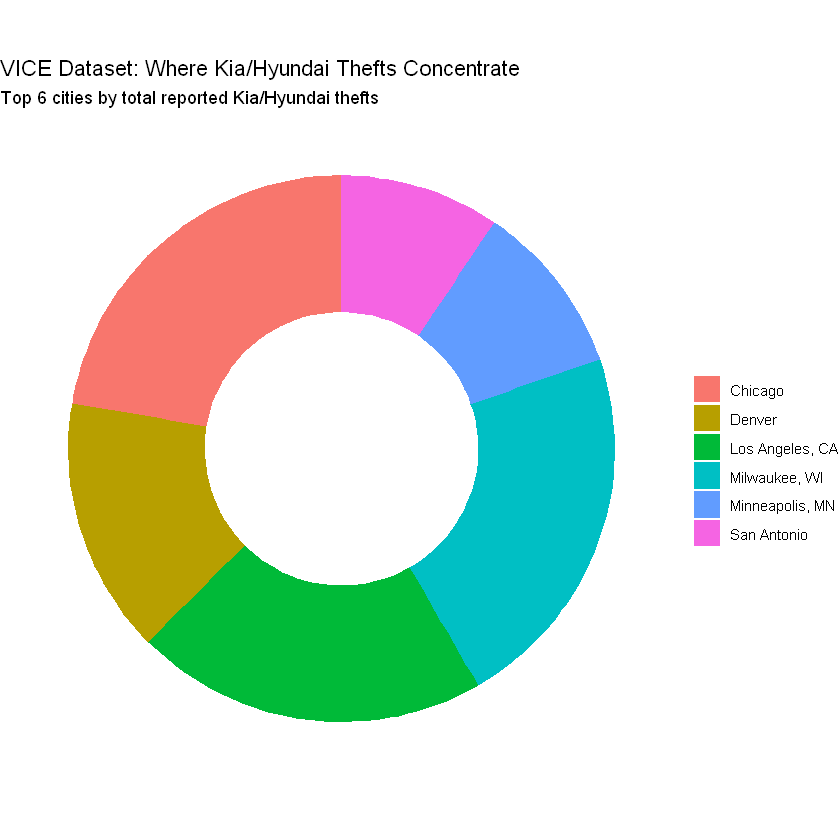

In [11]:
# VICE VISUAL (DONUT CHART)
# Summarize total thefts by city and show the top 6 for readability.

vice_city_totals = vice_long %>%
  group_by(city) %>%
  summarise(total_thefts = sum(theft_count, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_thefts)) %>%
  slice_head(n = 6)

ggplot(vice_city_totals, aes(x = 2, y = total_thefts, fill = city)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  xlim(0.5, 2.5) +
  labs(
    title = "VICE Dataset: Where Kia/Hyundai Thefts Concentrate",
    subtitle = "Top 6 cities by total reported Kia/Hyundai thefts",
    fill = ""
  ) +
  theme_void()


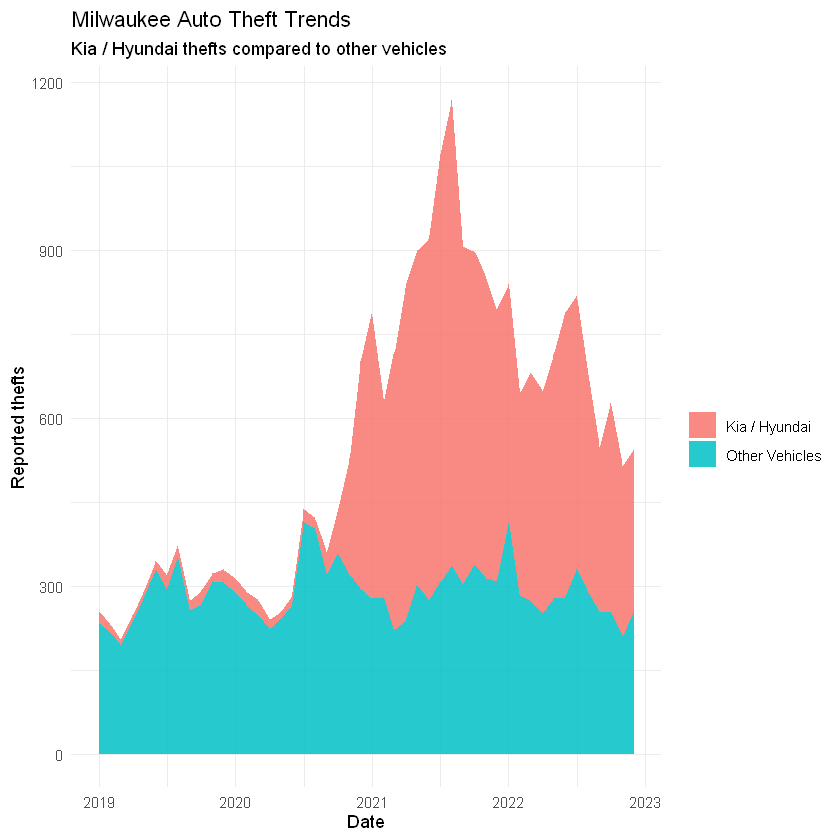

In [12]:
# Reshape Milwaukee theft data to compare Kia/Hyundai thefts
# against all other vehicle thefts over time

mw_long = mw %>%
  select(date, countKiaHyundaiThefts, countOtherThefts) %>%
  pivot_longer(
    cols = c(countKiaHyundaiThefts, countOtherThefts),
    names_to = "type",
    values_to = "count"
  ) %>%
  mutate(
    type = recode(
      type,
      countKiaHyundaiThefts = "Kia / Hyundai",
      countOtherThefts = "Other Vehicles"
    )
  )

# Visualize total theft volume using a stacked area chart
ggplot(mw_long, aes(x = date, y = count, fill = type)) +
  geom_area(alpha = 0.85) +
  labs(
    title = "Milwaukee Auto Theft Trends",
    subtitle = "Kia / Hyundai thefts compared to other vehicles",
    x = "Date",
    y = "Reported thefts",
    fill = ""
  ) +
  theme_minimal()



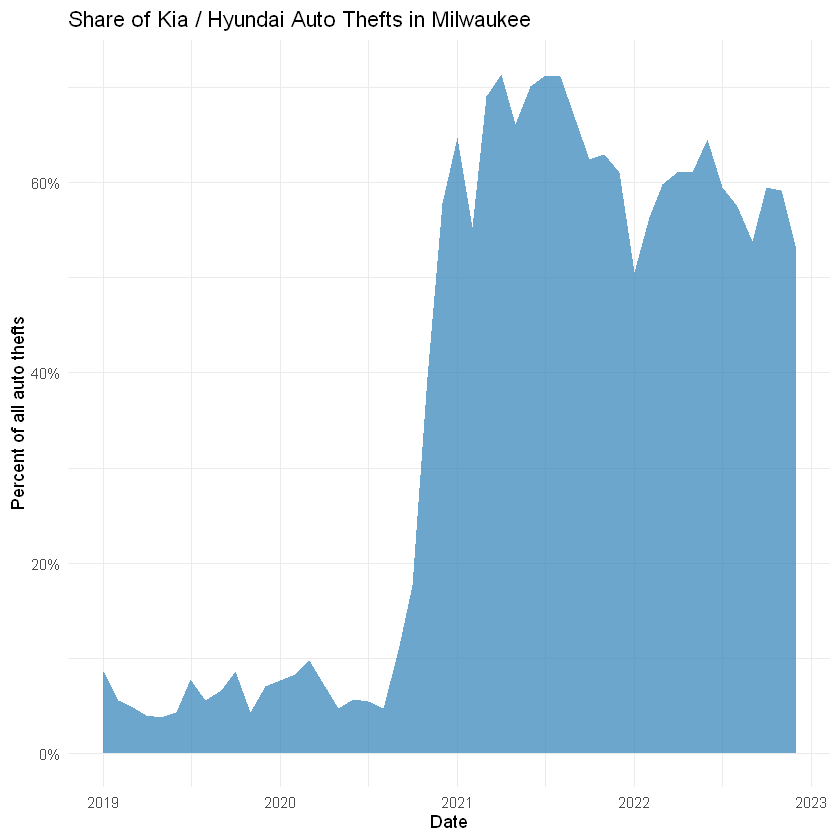

In [13]:
# Display the proportion of total auto thefts attributed
# to Kia and Hyundai vehicles in Milwaukee over time

ggplot(mw, aes(x = date, y = percentKiaHyundai)) +
  geom_area(fill = "#2c7fb8", alpha = 0.7) +
  scale_y_continuous(labels = percent_format()) +
  labs(
    title = "Share of Kia / Hyundai Auto Thefts in Milwaukee",
    x = "Date",
    y = "Percent of all auto thefts"
  ) +
  theme_minimal()



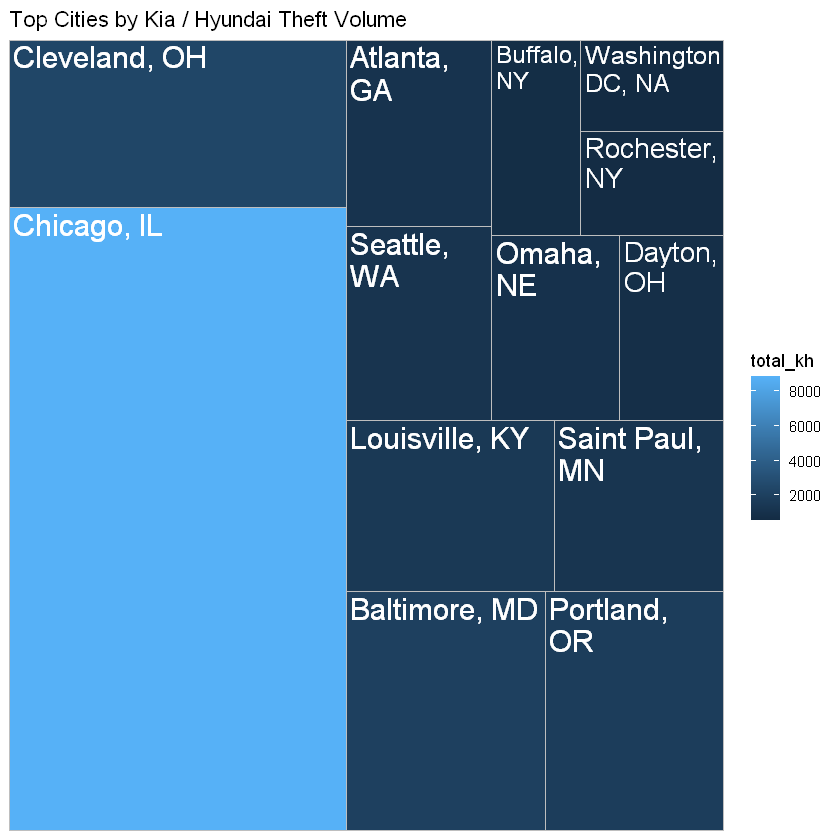

In [14]:
# Aggregate Kia/Hyundai theft counts by city
# Treemap emphasizes which cities contribute the most to total theft volume

city_totals = thefts %>%
  group_by(city, state) %>%
  summarise(
    total_kh = sum(countKiaHyundaiThefts, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(total_kh)) %>%
  slice_head(n = 15) %>%
  mutate(city_label = paste(city, state, sep = ", "))

ggplot(city_totals, aes(
  area = total_kh,
  fill = total_kh,
  label = city_label
)) +
  geom_treemap() +
  geom_treemap_text(reflow = TRUE, colour = "white") +
  labs(
    title = "Top Cities by Kia / Hyundai Theft Volume"
  ) +
  theme_minimal()


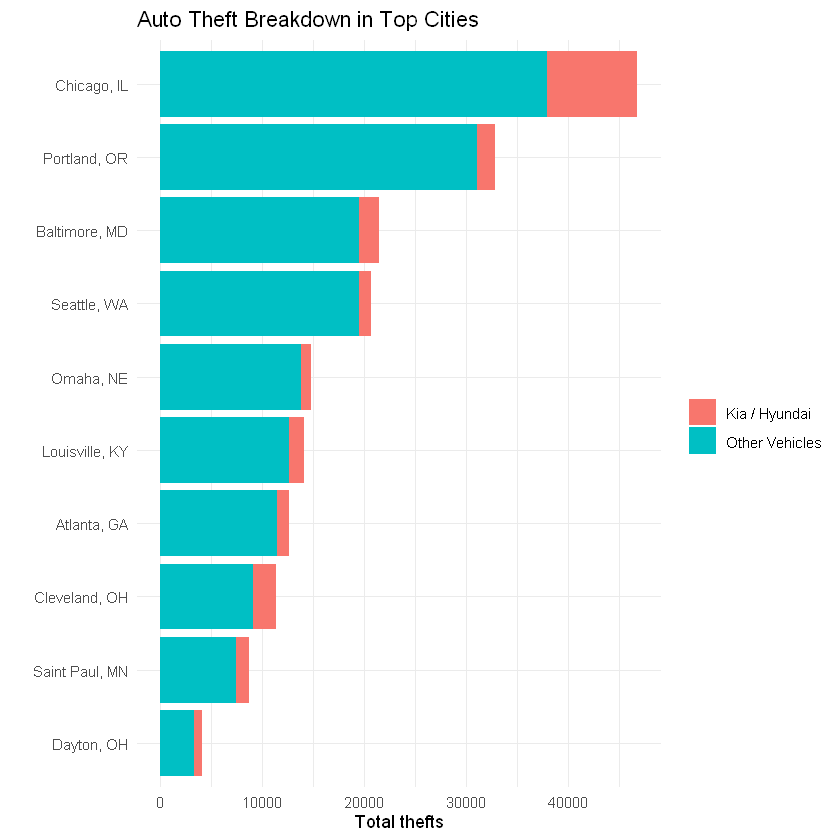

In [15]:
# Compare Kia/Hyundai thefts against other vehicle thefts
# across the top cities with the highest Kia/Hyundai theft counts

city_stack = thefts %>%
  group_by(city, state) %>%
  summarise(
    kh = sum(countKiaHyundaiThefts, na.rm = TRUE),
    other = sum(countOtherThefts, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(kh)) %>%
  slice_head(n = 10) %>%
  mutate(city_label = paste(city, state, sep = ", ")) %>%
  pivot_longer(
    cols = c(kh, other),
    names_to = "type",
    values_to = "count"
  ) %>%
  mutate(
    type = recode(type,
                  kh = "Kia / Hyundai",
                  other = "Other Vehicles")
  )

ggplot(city_stack, aes(x = reorder(city_label, count), y = count, fill = type)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Auto Theft Breakdown in Top Cities",
    x = "",
    y = "Total thefts",
    fill = ""
  ) +
  theme_minimal()



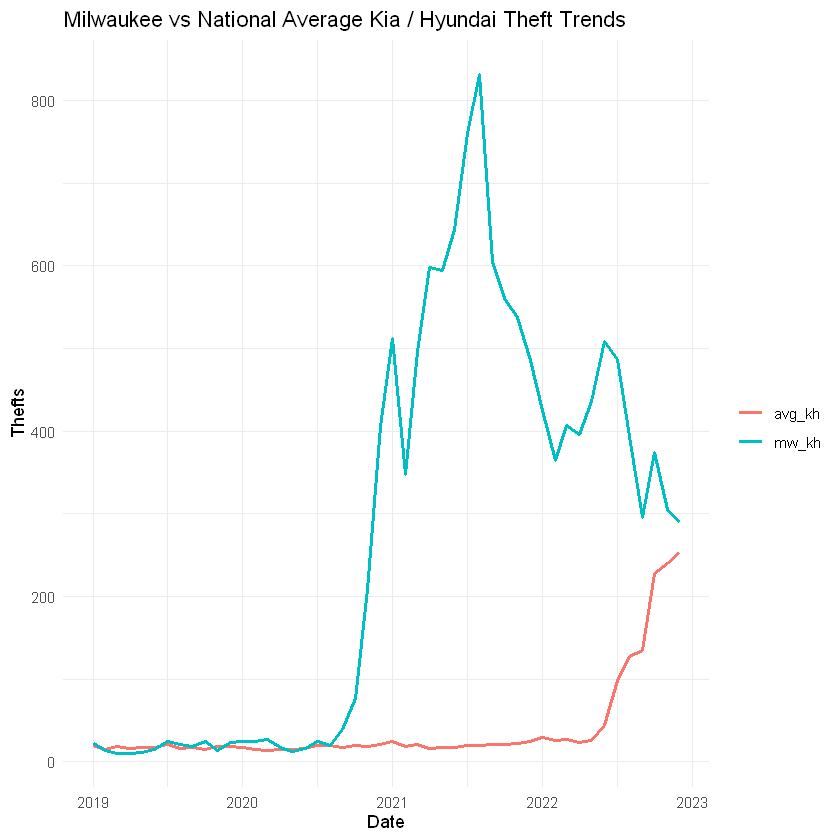

In [16]:
# Compare Milwaukee's Kia/Hyundai theft trend
# to the national average across all cities

avg_trend = thefts %>%
  group_by(date) %>%
  summarise(
    avg_kh = mean(countKiaHyundaiThefts, na.rm = TRUE)
  )

compare = mw %>%
  select(date, mw_kh = countKiaHyundaiThefts) %>%
  left_join(avg_trend, by = "date") %>%
  pivot_longer(
    cols = c(mw_kh, avg_kh),
    names_to = "series",
    values_to = "count"
  )

ggplot(compare, aes(x = date, y = count, color = series)) +
  geom_line(linewidth = 1) +
  labs(
    title = "Milwaukee vs National Average Kia / Hyundai Theft Trends",
    x = "Date",
    y = "Thefts",
    color = ""
  ) +
  theme_minimal()



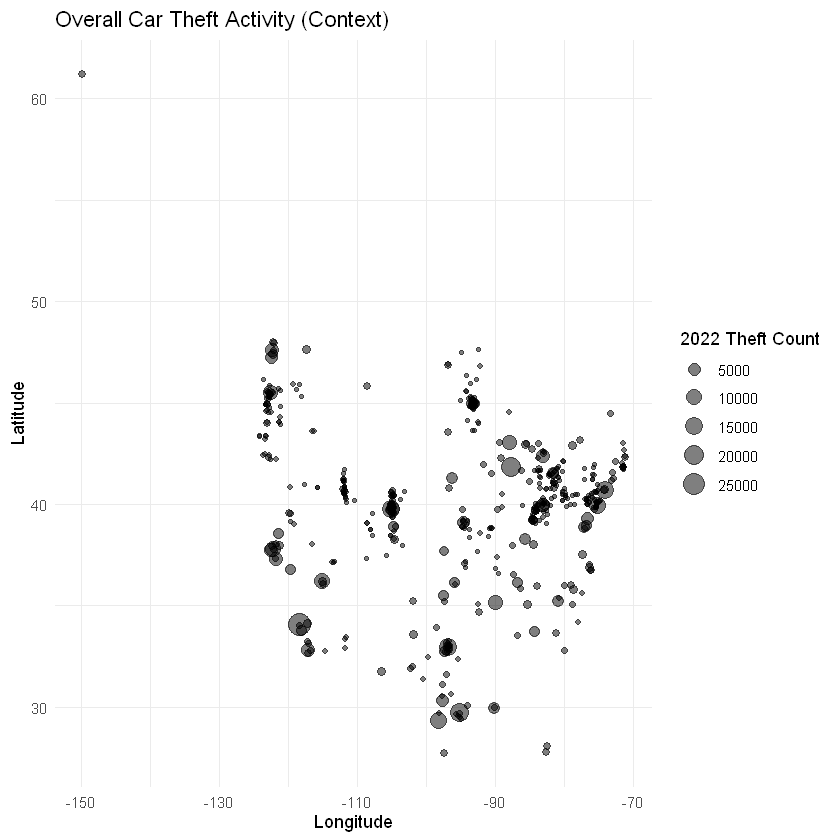

In [17]:
# Provide geographic context by visualizing overall car theft activity
# using agency-level location and theft volume

ggplot(mapdf, aes(x = longitude, y = latitude)) +
  geom_point(aes(size = countCarThefts2022), alpha = 0.5) +
  labs(
    title = "Overall Car Theft Activity (Context)",
    x = "Longitude",
    y = "Latitude",
    size = "2022 Theft Count"
  ) +
  theme_minimal()
